## Fitting an unbroken power law to the HESE 7.5 year data

In [1]:
# Loading the HESE 7.5 year data

import numpy as np
import GollumFitPy as gf
import scipy.stats as stats
import os 

import sys
sys.path.append("Data/HESE/HESE 7.5 Data Release")
import data_loader 

In [22]:
# Importing the data

HESE_75 = data_loader.load_data("Data/HESE/HESE 7.5 Data Release/resources/data/HESE_data.json")

HESE_75_mc_files = [
        "Data/HESE/HESE 7.5 Data Release/resources/data/HESE_mc_observable.json",
        "Data/HESE/HESE 7.5 Data Release/resources/data/HESE_mc_flux.json",
        "Data/HESE/HESE 7.5 Data Release/resources/data/HESE_mc_truth.json",
    ]

HESE_75_mc = data_loader.load_mc(HESE_75_mc_files)

HESE_75_Energy = np.array([i[0] for i in HESE_75])
HESE_75_Zenith = np.array([i[1] for i in HESE_75])
HESE_75_EventType = np.array([i[3] for i in HESE_75])

In [14]:
HESE_75_mc

array([(464800.948806  , 2.42233048, 12, 205266.25     , 2.29610848, nan, 0,  3185171.50222989, 0.00000000e+00, 1.17806034e-26, 5.90371965e-23, 7.35794334e-22, 1.        , 1.        , 5.31231755, -0.66336906, nan),
       (134045.49727878, 0.87934696, 12,  70989.9921875, 1.22285497, nan, 0,   856308.74936622, 0.00000000e+00, 8.82579793e-24, 1.08009962e-20, 3.70537697e-20, 0.10632036, 0.04538098, 4.85119713,  0.34096325, nan),
       (677478.79879724, 1.47516781, 12, 874167.1875   , 1.00446963, nan, 0, 15194421.72712283, 0.00000000e+00, 5.46804419e-26, 7.25172174e-23, 2.14404540e-22, 0.92758852, 0.89264524, 5.9415945 ,  0.53653585, nan),
       ...,
       (549664.26022818, 1.27896744, 13, 196890.75     , 1.27311492, nan, 1,        0.        , 1.03564969e-11, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.        , 1.        , 5.29422531,  0.29330438, nan),
       (127729.52330582, 1.1578394 , 13,  92714.1171875, 1.1827147 , nan, 1,        0.        , 6.12933451e-10, 0.00000000e+00, 

In [41]:
# Reformatting the data for Gollum

HESE_reformatted = np.zeros((len(HESE_75), 3))
HESE_reformatted[:, 0] = HESE_75_Energy
HESE_reformatted[:, 1] = HESE_75_Zenith
HESE_reformatted[:, 2] = HESE_75_EventType

# Choosing the events with zenith angle greater than 90 degrees (upgoing events)
# Data is in radians, so use np.pi / 2
# mask = HESE_reformatted[:, 1] > (np.pi / 2)
# HESE_reformatted = HESE_reformatted[mask]

# events with energy less than 1e5 GeV 

mask = HESE_reformatted[:, 0] < 1e7
HESE_reformatted = HESE_reformatted[mask]

# Saving the reformatted data

np.savez("Data/GollumFit_Data/HESE_7.5_year.npz", HESE_75=HESE_reformatted)

In [44]:
np.load("Data/GollumFit_Data/HESE_7.5_year.npz")['HESE_75']

array([[9.84745781e+04, 1.42272401e+00, 0.00000000e+00],
       [7.05925078e+04, 9.55264986e-01, 1.00000000e+00],
       [1.84547453e+05, 9.12687302e-01, 0.00000000e+00],
       [8.54191641e+04, 1.26426971e+00, 0.00000000e+00],
       [7.43091016e+04, 1.49489570e+00, 0.00000000e+00],
       [8.64801953e+04, 8.66718948e-01, 0.00000000e+00],
       [2.52038031e+05, 2.02022028e+00, 0.00000000e+00],
       [1.03547962e+06, 1.54292607e+00, 0.00000000e+00],
       [1.71397406e+05, 1.96363652e+00, 0.00000000e+00],
       [6.16864570e+04, 5.59278965e-01, 0.00000000e+00],
       [1.25573625e+06, 4.21025991e-01, 0.00000000e+00],
       [1.95833469e+05, 1.11062574e+00, 0.00000000e+00],
       [8.60804453e+04, 2.93880272e+00, 0.00000000e+00],
       [1.86558625e+05, 2.06770587e+00, 0.00000000e+00],
       [1.07340828e+05, 6.61084726e-02, 0.00000000e+00],
       [3.33548500e+05, 1.67270017e+00, 1.00000000e+00],
       [1.79998412e+06, 5.55401862e-01, 2.00000000e+00],
       [1.86010953e+05, 1.83494

In [174]:
np.random.randint(0, 100, 102)

array([20, 33, 36,  0, 41, 20, 97, 65, 21, 48, 11, 73, 29, 55, 66, 99, 32,
       82, 19, 74, 99, 46, 47, 30, 59, 98, 15, 35, 91, 33, 39, 91, 85, 29,
       38, 96, 30, 45, 66, 21, 78, 99,  4, 67, 18, 72, 75, 24, 57, 19, 35,
       48, 64, 18, 85, 74, 57, 99,  8, 81, 72, 54, 30, 30, 91, 15, 57, 50,
       22, 32, 35, 59, 75,  0, 12, 66, 29, 63, 34, 30, 62, 68, 78, 34, 76,
       49, 36, 10, 14, 88, 79, 15, 31, 58, 10, 15, 71, 51, 58, 64, 80, 16])

In [2]:
# Selecting just a few events from a fake events dataset that was created from one of the examples 
# check if the fit is possible with just using these many event points 

# fake_data = np.load("GollumFit/GollumFit/examples/fitting_to_null/nullexpectation.npz")['realization'] 
fake_data = np.load("Data/GollumFit_Data/modified_fake_data.npz")['realization']

# Randomly selecting a smaller number of events from this dataset 
np.random.seed(100) # for reproducibiility 

# fake_events = fake_data[np.random.randint(0, len(fake_data), int(7e4))] 
fake_events = fake_data  

# saving it to a .npz file 
np.savez("Data/GollumFit_Data/fake_events.npz", fake = fake_events)

In [3]:
len(fake_events)

13061947

---

### Initializing FastMC

In [2]:
#####################################################################################
# Configure Data Paths - Set paths for cross section splines
#####################################################################################
datapaths = gf.DataPaths()
gollumdir = "GollumFit/GollumFit"


datapaths.neutrino_cc_xs_spline_path             = gollumdir + "/resources/Splines/CrossSections/sigma_nu_CC_iso.fits"
datapaths.antineutrino_cc_xs_spline_path         = gollumdir + "/resources/Splines/CrossSections/sigma_nubar_CC_iso.fits"
datapaths.neutrino_nc_xs_spline_path             = gollumdir + "/resources/Splines/CrossSections/sigma_nu_NC_iso.fits"
datapaths.antineutrino_nc_xs_spline_path         = gollumdir + "/resources/Splines/CrossSections/sigma_nubar_NC_iso.fits"
datapaths.diff_neutrino_cc_xs_spline_path        = gollumdir + "/resources/Splines/CrossSections/dsdxdy_nu_CC_iso.fits"
datapaths.diff_antineutrino_cc_xs_spline_path    = gollumdir + "/resources/Splines/CrossSections/dsdxdy_nubar_CC_iso.fits"
datapaths.diff_neutrino_nc_xs_spline_path        = gollumdir + "/resources/Splines/CrossSections/dsdxdy_nu_NC_iso.fits"
datapaths.diff_antineutrino_nc_xs_spline_path    = gollumdir + "/resources/Splines/CrossSections/dsdxdy_nubar_CC_iso.fits"
datapaths.mc_path                                = gollumdir + "/monte_carlo/"
datapaths.domeff_spline_path                     = gollumdir + "/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
datapaths.holeice_spline_path                    = gollumdir + "/resources/Splines/HoleIceSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
datapaths.attenuation_spline_path                = gollumdir + "/resources/Splines/AttenuationSplines/new_ddmnodeis"
datapaths.ice_gradient_spline_path               = gollumdir + "/resources/Splines/IceGradientsSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
datapaths.atmospheric_density_spline_path        = gollumdir + "/resources/Splines/AtmosphericZenithVariationSplines/atm_density_1s.fits"
datapaths.atmospheric_kaonlosses_spline_path     = gollumdir + "/resources/Splines/AtmosphericKaonLossesSplines/kaon_loses_1s.fits"


# datapaths.domeff_spline_path                     = "Data/HESE/HESE 7.5 Data Release/resources/splines/Gollum-test-splines"



In [3]:
#####################################################################################
# Configure Flux Files - Load atmospheric, prompt, and astrophysical flux files
#####################################################################################
datapaths.conventional_nusquids_atmospheric_file = gollumdir + "/examples/fluxes/atmospheric.hdf5"
datapaths.prompt_nusquids_atmospheric_file       = gollumdir + "/examples/fluxes/prompt_atmospheric.hdf5"
datapaths.astro_nusquids_file                    = gollumdir + "/examples/fluxes/astro.hdf5"

# Hadronic and cosmic ray correction splines (necessary for flux nuisance parameters)
hadronlist = ["he_K+", "he_K-", "vhe1_pi+", "vhe1_pi-", "vhe3_K+", "vhe3_K-", 
              "vhe3_pi+", "vhe3_pi-", "vhe3_p", "vhe3_n"]
crlist = ["GSF_1", "GSF_2", "GSF_3", "GSF_4", "GSF_5", "GSF_6"]

datapaths.hadronic_spline_path   = gollumdir + "/examples/fluxes"
datapaths.cosmic_ray_spline_path = gollumdir + "/examples/fluxes"

In [4]:
#####################################################################################
# Set Steering Parameters - Configure analysis binning and settings
# NOTE: Binning choices affect FastMC compression and must match analysis configuration
#####################################################################################
steering_params = gf.SteeringParams()
steering_params.minFitEnergy                    = 300
steering_params.maxFitEnergy                    = 1e5
steering_params.logEbinEdge                     = np.log10(300)
steering_params.logEbinWidth                    = (np.log10(1e5) - np.log10(300)) / 24
steering_params.minCosth                        = -1.0
steering_params.maxCosth                        = 0.0
steering_params.cosThbinEdge                    = 0.0
steering_params.cosThbinWidth                   = 0.05
steering_params.selectionStart                  = 0.99
steering_params.ice_gradient_filename           = ["Amp_0", "Amp_1", "Amp_2", "Amp_3", "Amp_4", 
                                                   "Phs_1", "Phs_2", "Phs_3", "Phs_4"]
steering_params.active_hadronic_parameters      = hadronlist
steering_params.active_cosmicray_parameters     = crlist

# Livetime for the corresponding Monte Carlo
years = 10.669
steering_params.fullLivetime                    = years * 365 * 24 * 60 * 60.
steering_params.simToLoad                       = "BDT_Split_HE"
steering_params.energyName                      = "DnnEnergy"
steering_params.model_label                     = ""  # Can be used for uniquely-labelled flux files

In [5]:
#####################################################################################
# Construct and Write FastMC
#####################################################################################
gollumfit = gf.GollumFit(datapaths, steering_params)

# Compression parameter: smaller values = higher compression but potential accuracy loss
metascaling = 0.25
gollumfit.ConstructFastMode(metascaling)

# Write to file
gollumfit.WriteCompact("Data/GollumFit_Data/compact.fastmc")

print("Done generating FastMC.")

reset_steering: 1
reset_data: 1
Loading DOM efficiency splines...
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_atmConv_track.fits
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_atmConv_shower.fits
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_atmPrompt_track.fits
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_atmPrompt_shower.fits
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_diffuseAstro_track.fits
Checking file from path GollumFit/GollumFit/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99/domefficiency_spline_stacked_

---

### Generating and minimizing likelihood

In [2]:
#####################################################################################
# Define Nuisance Parameters (All set to vary in fit with False flag)
# Format: [vary_flag, prior_type, center, width, lower_bound, upper_bound]
#####################################################################################
# syst_dict     = { 
#     'convNorm'                  : [ False, 'Gaussian',      1.,   0.2,                   0.1,                   3. ], 
#     'zenithCorrection'          : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'kaonLosses'                : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'hadronicHEkp'              : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicHEkm'              : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE1pip'           : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE1pim'           : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE3kp'            : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE3km'            : [ False, 'Gaussian',      0.,    1.,                  -1.5,                   2. ], 
#     'hadronicVHE3pip'           : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE3pim'           : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE3p'             : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'hadronicVHE3n'             : [ False, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
#     'cosmicRay1'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'cosmicRay2'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'cosmicRay3'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'cosmicRay4'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'cosmicRay5'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'cosmicRay6'                : [ False, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
#     'icegrad0'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad1'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad2'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad3'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad4'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad5'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad6'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad7'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'icegrad8'                  : [ False, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
#     'domEfficiency'             : [ False, 'Gaussian',    1.27, 0.123,                 1.234,                1.346 ], 
#     'holeiceForward'            : [ False, 'Gaussian',     -1.,   10.,                 -5.35,                 1.85 ], 
#     'astroNorm'                 : [ False, 'Gaussian', 4.72/6.,  0.36,                    0.,                   3. ], 
#     'astroDeltaGamma'           : [ False, 'Gaussian',      0.,  0.36,                   -2.,                   2. ], 
#     'astroDeltaGammaSec'        : [ False, 'Gaussian',      0.,  0.36,                   -2.,                   2. ], 
#     'nuxs'                      : [ False, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
#     'nubarxs'                   : [ False, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
#     'astroPivot'                : [ False,  'Uniform',      5.,    1.,                    4.,                   6. ], 
#     'promptNorm'                : [ False, 'Gaussian',      1.,    1.,                    0.,                   3. ],
#     'NeutrinoAntineutrinoRatio' : [ False, 'Gaussian',      1.,    1.,                    0.,                   2. ],
# }

# Only astro parameters |

syst_dict     = { 
    'convNorm'                  : [ False, 'Gaussian',      1.,   0.8,                   0.1,                   3. ], 
    'zenithCorrection'          : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'kaonLosses'                : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'hadronicHEkp'              : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicHEkm'              : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE1pip'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE1pim'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3kp'            : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3km'            : [ True, 'Gaussian',      0.,    1.,                  -1.5,                   2. ], 
    'hadronicVHE3pip'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3pim'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3p'             : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3n'             : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'cosmicRay1'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay2'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay3'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay4'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay5'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay6'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'icegrad0'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad1'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad2'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad3'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad4'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad5'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad6'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad7'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad8'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'domEfficiency'             : [ True, 'Gaussian',    1.27, 0.123,                 1.234,                1.346 ], 
    'holeiceForward'            : [ True, 'Gaussian',     -1.,   10.,                 -5.35,                 1.85 ], 
    'astroNorm'                 : [ False, 'Gaussian',      5.,  3.,                    4.,                   8. ], 
    'astroDeltaGamma'           : [ False, 'Gaussian',      0.,  0.36,                   -2.,                   2. ], 
    'astroDeltaGammaSec'        : [ False, 'Gaussian',      0.,  0.36,                   -2.,                   2. ], 
    'nuxs'                      : [ False, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
    'nubarxs'                   : [ False, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
    'astroPivot'                : [ False,  'Uniform',      5.,    1.,                    4.,                   6. ], 
    'promptNorm'                : [ False, 'Gaussian',      1.,    1.,                    0.,                   3. ],
    'NeutrinoAntineutrinoRatio' : [ False, 'Gaussian',      1.,    1.,                    0.,                   2. ],
}

In [3]:
#####################################################################################
# Define Random Sampling Function
# Helper function to sample random parameter values from prior distributions
#####################################################################################
# def throw(syst):
#     """Sample random value from prior distribution."""
#     if syst[1] == 'Gaussian':
#         # Truncated normal distribution
#         val = stats.truncnorm(
#             (syst[4] - syst[2]) / syst[3],  # Lower bound (standardized)
#             (syst[5] - syst[2]) / syst[3],  # Upper bound (standardized)
#             syst[2],  # Mean
#             syst[3]   # Std dev
#         ).rvs(1)
#         return val[0]
#     else:
#         # Uniform distribution
#         return np.random.uniform(syst[4], syst[5])


# modifying throw() so that it outputs the mean value of the parameter if the parameter is non-varying
# and randomly initializes the varying parameters 

def throw(syst):
    """Sample random value from prior distribution."""

    if syst[0] == False:
        if syst[1] == 'Gaussian':
            # Truncated normal distribution
            val = stats.truncnorm(
                (syst[4] - syst[2]) / syst[3],  # Lower bound (standardized)
                (syst[5] - syst[2]) / syst[3],  # Upper bound (standardized)
                syst[2],  # Mean
                syst[3]   # Std dev
            ).rvs(1)
            return val[0]
        else:
            # Uniform distribution
            return np.random.uniform(syst[4], syst[5])
    else:
        return syst[2]

In [4]:
#####################################################################################
# Initialize Fit Parameter Objects
# Create objects to manage fit configuration
#####################################################################################

fitparams_flag  = gf.FitParametersFlag()  # Which parameters to vary
fitparams_bound = gf.FitParametersBound()  # Parameter bounds
priors          = gf.Priors()              # Prior distributions
seed_fitparams  = gf.FitParameters()       # Initial values

In [5]:
#####################################################################################
# Set Priors and Random Initial Values
# Configure priors and randomly initialize starting parameter values
#####################################################################################
np.random.seed(101)  # For reproducibility
print('Initializing with the following randomly-seeded nuisance params:')

for sname in syst_dict.keys():
    # Set flags and bounds
    exec(f'fitparams_flag.{sname} = syst_dict["{sname}"][0]')
    exec(f'fitparams_bound.{sname}Min = syst_dict["{sname}"][4]')
    exec(f'fitparams_bound.{sname}Max = syst_dict["{sname}"][5]')
    
    # Set priors
    if syst_dict[sname][1] == 'Gaussian':
        exec(f'priors.{sname}Center = syst_dict["{sname}"][2]')
        exec(f'priors.{sname}Width  = syst_dict["{sname}"][3]')
    else:
        exec(f'priors.{sname}Min = syst_dict["{sname}"][4]')
        exec(f'priors.{sname}Max = syst_dict["{sname}"][5]')
    
    # Randomly initialize
    thrown_val = throw(syst_dict[sname])
    exec(f'seed_fitparams.{sname} = thrown_val')
    print(f'{sname}: {thrown_val}')

Initializing with the following randomly-seeded nuisance params:
convNorm: 1.153750491903771
zenithCorrection: 0.0
kaonLosses: 0.0
hadronicHEkp: 0.0
hadronicHEkm: 0.0
hadronicVHE1pip: 0.0
hadronicVHE1pim: 0.0
hadronicVHE3kp: 0.0
hadronicVHE3km: 0.0
hadronicVHE3pip: 0.0
hadronicVHE3pim: 0.0
hadronicVHE3p: 0.0
hadronicVHE3n: 0.0
cosmicRay1: 0.0
cosmicRay2: 0.0
cosmicRay3: 0.0
cosmicRay4: 0.0
cosmicRay5: 0.0
cosmicRay6: 0.0
icegrad0: 0.0
icegrad1: 0.0
icegrad2: 0.0
icegrad3: 0.0
icegrad4: 0.0
icegrad5: 0.0
icegrad6: 0.0
icegrad7: 0.0
icegrad8: 0.0
domEfficiency: 1.27
holeiceForward: -1.0
astroNorm: 6.065289238587592
astroDeltaGamma: -0.6853341752717854
astroDeltaGammaSec: -0.3413409074459866
nuxs: 1.0441984585895245
nubarxs: 1.0869513154905492
astroPivot: 4.613932439344476
promptNorm: 2.2273906901240403
NeutrinoAntineutrinoRatio: 1.3886856931236742


In [6]:
#####################################################################################
# Set Correlations and Paths
# Load correlation matrices for ice gradients and flux parameters
#####################################################################################
gollumdir = "GollumFit/GollumFit"

# Set correlations (required for fitting/minimization, not for likelihood evaluation)
iceg_corr = np.load(gollumdir + '/resources/correlation_matrices/icegrad_correlations.npy')
flux_corr = np.load(gollumdir + '/resources/correlation_matrices/flux_correlations_new_ddmnodeis.npy')
for idx, val in np.ndenumerate(iceg_corr):
    priors.SetIceGradientsCorr(idx[0], idx[1], val)
for idx, val in np.ndenumerate(flux_corr):
    priors.SetFluxCorr(idx[0], idx[1], val)

datapaths = gf.DataPaths()
datapaths.domeff_spline_path      = "" #gollumdir + "/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
datapaths.holeice_spline_path     = "" #gollumdir + "/resources/Splines/HoleIceSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
datapaths.attenuation_spline_path = "" #gollumdir + "/resources/Splines/AttenuationSplines/new_ddmnodeis"


# datapaths.domeff_spline_path      = gollumdir + "/resources/Splines/DOMEffSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
# datapaths.holeice_spline_path     = gollumdir + "/resources/Splines/HoleIceSplines/new_ddmnodeis/BDT/DnnEnergy_0.99"
# datapaths.attenuation_spline_path = gollumdir + "/resources/Splines/AttenuationSplines/new_ddmnodeis"

datapaths.compact_file_path       = 'Data/GollumFit_Data/compact.fastmc'
# datapaths.compact_file_path       = gollumdir + "/examples/FastMC/compact.fastmc"

In [7]:
#####################################################################################
# Configure Steering Parameters
# Set binning and convergence criteria (must match FastMC binning)
#####################################################################################
# edges = np.logspace(np.log10(300), np.log10(1e5), 25)
# steering_params                = gf.SteeringParams()
# steering_params.minFitEnergy   = edges[0]
# steering_params.maxFitEnergy   = edges[-1]
# steering_params.logEbinEdge    = np.log10(edges[0])
# steering_params.logEbinWidth   = np.log10(edges[1]) - np.log10(edges[0])
# steering_params.minCosth       = -1.0
# steering_params.maxCosth       = 0.0
# steering_params.cosThbinEdge   = 0.0
# steering_params.cosThbinWidth  = 0.05
# steering_params.selectionStart = float("DnnEnergy_0.99".split("_")[1])
# steering_params.evalThreads    = 1

steering_params = gf.SteeringParams()
steering_params.minFitEnergy                    = 60000
steering_params.maxFitEnergy                    = 1e7
steering_params.logEbinEdge                     = np.log10(60000)
steering_params.logEbinWidth                    = 0.111
steering_params.minCosth                        = -1.0
steering_params.maxCosth                        = 1.0
steering_params.cosThbinEdge                    = 0.0
steering_params.cosThbinWidth                   = 0.2
steering_params.selectionStart                  = float("DnnEnergy_0.99".split("_")[1])
steering_params.evalThreads                     = 1

# Convergence criteria (tight tolerances for accurate minimization)
steering_params.change_tol     = 1.e-20
steering_params.grad_tol       = 1.e-20
steering_params.uncertaintyModSigmaOverMu = 0.0

In [8]:
#####################################################################################
# Load Data and Configure Fit
# Create GollumFit object and load pseudo-data
#####################################################################################
gollumfit = gf.GollumFit(datapaths, steering_params)

#####################################################################################
# declare the fake data location and load it
#####################################################################################
realization  = "Data/GollumFit_Data/fake_events.npz"
total_data = gollumfit.SetData(np.load(realization)["fake"])

reset_steering: 1
reset_data: 1
Constructing DiffuseWeightMaker
Loading compact data
Checking file from path Data/GollumFit_Data/compact.fastmc
Making sim hist
Remaking data hist


In [9]:
#####################################################################################
# feed the flags, bounds, priors, on the nuisance parameters into gollumfit
#####################################################################################
gollumfit.SetFitParametersFlag(fitparams_flag)
gollumfit.SetFitParametersBound(fitparams_bound)
gollumfit.SetFitParametersPriors(priors)
gollumfit.SetFitParametersSeed([seed_fitparams])
gollumfit.ConstructLikelihoodProblem()

In [10]:
#####################################################################################
# perform the minimization
#####################################################################################
print("Starting minimization...")
min_llh = gollumfit.MinLLH()

Starting minimization...
-17922.6 [-105.387,-2.36733,-0.269208,-0.435582,-0.039104,-0.00875166,-0.0179906,-0.00701962,-2.42619,-1.48333,-0.465943,-0.200182,-0.300072,-0.194949,-0.867725,-0.420784,0.213937,-0.17924,1.10577,-0.375626,-2.55162,-1.02927,-0.626562,0.174277,0.178441,-2.59835,-0.724541,0.297717,-0.0725481,0,0,-17.3245,5.17327,196.371,82.47,2.00103,-4.41985,-8.69514]
-18200.2 [-4088.87,0.862361,-0.0346995,-0.0606325,-0.00671918,-0.00137884,-0.00316139,-0.00117227,-0.333113,-0.198114,-0.0651634,-0.0279905,-0.0425228,-0.0276863,-0.119027,-0.0552124,0.0299181,-0.0251721,0.147924,-0.054404,-16.9528,-2.30992,-2.64307,-1.02624,2.3358,-24.5727,-1.54873,5.1833,1.8604,0,0,-101.639,-1117.93,-15.4321,-1874.3,58.6154,17.6,17.6]
-17882.5 [44.4417,0.245843,0.181721,0.305762,0.0307698,0.00680279,0.0146227,0.00576369,1.6955,1.004,0.326936,0.139468,0.212127,0.137926,0.603496,0.285443,-0.150129,0.124577,-0.75166,0.263461,1.15369,0.319852,0.222921,-0.00293426,-0.127749,1.43513,0.205065,-0.258624

In [11]:
#####################################################################################
# results: print the best fit nuisance parameters, likelihood, and the number of LLH evaluations
#####################################################################################
systematics = ""
for sname in syst_dict.keys() :
    exec('print(\"'+sname+'\",min_llh.params.'+sname+')')
    exec('systematics += str(min_llh.params.'+sname+')+\" \"')

print('llh:',min_llh.likelihood)
print('nEval: '+str(min_llh.nEval))

print("Completed successfully. Bye!")

convNorm 1.1527434587478638
zenithCorrection 0.0
kaonLosses 0.0
hadronicHEkp 0.0
hadronicHEkm 0.0
hadronicVHE1pip 0.0
hadronicVHE1pim 0.0
hadronicVHE3kp 0.0
hadronicVHE3km 0.0
hadronicVHE3pip 0.0
hadronicVHE3pim 0.0
hadronicVHE3p 0.0
hadronicVHE3n 0.0
cosmicRay1 0.0
cosmicRay2 0.0
cosmicRay3 0.0
cosmicRay4 0.0
cosmicRay5 0.0
cosmicRay6 0.0
icegrad0 0.0
icegrad1 0.0
icegrad2 0.0
icegrad3 0.0
icegrad4 0.0
icegrad5 0.0
icegrad6 0.0
icegrad7 0.0
icegrad8 0.0
domEfficiency 1.2699999809265137
holeiceForward -1.0
astroNorm 5.532171249389648
astroDeltaGamma 0.012356765568256378
astroDeltaGammaSec 0.22863070666790009
nuxs 1.0
nubarxs 1.0
astroPivot 4.742393493652344
promptNorm 1.0337427854537964
NeutrinoAntineutrinoRatio 1.0272434949874878
llh: 17875.330305286072
nEval: 47
Completed successfully. Bye!


---

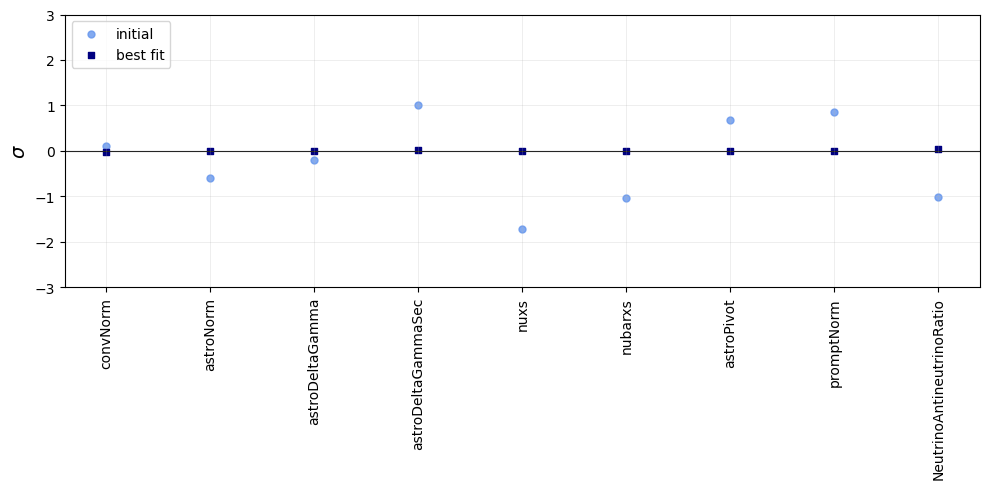

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Input Data
init_raw = {
    "convNorm": 1.0485, "astroNorm": 5.4641,
    "astroDeltaGamma": 0.3319, "astroDeltaGammaSec": 0.5729, "nuxs": 0.8289,
    "nubarxs": 0.8969, "astroPivot": 5.3415, "promptNorm": 2.2959,
    "NeutrinoAntineutrinoRatio": 0.4887
}

fit_raw = {
    "convNorm": 1.0044, "astroNorm": 6.3702,
    "astroDeltaGamma": 0.3703, "astroDeltaGammaSec": 0.3751, "nuxs": 1.0000,
    "nubarxs": 1.0000, "astroPivot": 5.0024, "promptNorm": 0.0070,
    "NeutrinoAntineutrinoRatio": 1.0162
}

# 2. Prior Definitions
# Enter your actual prior means and standard deviations here.
# By default, I am setting the mean to the Fit value to center them at 0.
# Update 'prior_sigmas' with your actual values.
prior_means = {
    "convNorm": 1.01, "astroNorm": 6.37,
    "astroDeltaGamma": 0.37, "astroDeltaGammaSec": 0.37, "nuxs": 1.0000,
    "nubarxs": 1.0000, "astroPivot": 5.00, "promptNorm": 0.00,
    "NeutrinoAntineutrinoRatio": 1.0
}
prior_sigmas = {
    "convNorm": 0.68/2, "astroNorm": 3.08/2,
    "astroDeltaGamma": 0.4/2, "astroDeltaGammaSec": 0.4/2, "nuxs": 0.1000,
    "nubarxs": 0.10000, "astroPivot": 1.00/2, "promptNorm": 5.34/2,
    "NeutrinoAntineutrinoRatio": 1.0/2
} # REPLACE 1.0 with your sigma values

# Example overrides (adjust as needed):
# prior_sigmas['convNorm'] = 0.4
# prior_sigmas['domEfficiency'] = 0.1

# 3. Calculate Pulls
params = list(fit_raw.keys())
init_pulls = [(init_raw[p] - prior_means[p]) / prior_sigmas[p] for p in params]
fit_pulls = [(fit_raw[p] - prior_means[p]) / prior_sigmas[p] for p in params]

# 4. Plotting
plt.figure(figsize=(10, 5))

# Plot initial values (light blue circles)
plt.scatter(params, init_pulls, color='#6495ED', label='initial', marker='o', s=25, alpha=0.8)

# Plot best fit values (dark blue squares)
plt.scatter(params, fit_pulls, color='#000080', label='best fit', marker='s', s=25)

# Formatting
plt.axhline(0, color='black', linewidth=0.8, zorder=1)
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.3)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.xticks(rotation=90)
plt.ylim(-3, 3) # Standard pull range
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.show()

In [ ]:
syst_dict     = OrderedDict({ 
    'convNorm'                  : [ True, 'Gaussian',      1.01,   0.68/2,                   0.1,                   3. ], 
    'zenithCorrection'          : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'kaonLosses'                : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'hadronicHEkp'              : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicHEkm'              : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE1pip'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE1pim'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3kp'            : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3km'            : [ True, 'Gaussian',      0.,    1.,                  -1.5,                   2. ], 
    'hadronicVHE3pip'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3pim'           : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3p'             : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'hadronicVHE3n'             : [ True, 'Gaussian',      0.,    1.,                   -2.,                   2. ], 
    'cosmicRay1'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay2'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay3'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay4'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay5'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'cosmicRay6'                : [ True, 'Gaussian',      0.,    1.,                   -4.,                   4. ], 
    'icegrad0'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad1'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad2'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad3'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad4'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad5'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad6'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad7'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'icegrad8'                  : [ True, 'Gaussian',      0.,    1.,                   -3.,                   3. ], 
    'domEfficiency'             : [ True, 'Gaussian',    1.27, 0.123,                 1.234,                1.346 ], 
    'holeiceForward'            : [ True, 'Gaussian',     -1.,   10.,                 -5.35,                 1.85 ], 
    'astroNorm'                 : [ True, 'Gaussian',     6.37,  3.08/2,                    4.,                   8. ], 
    'astroDeltaGamma'           : [ True, 'Gaussian',      0.37,  0.4/2,                   -2.,                   2. ], 
    'astroDeltaGammaSec'        : [ True, 'Gaussian',      0.37,  0.4/2,                   -2.,                   2. ], 
    'nuxs'                      : [ True, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
    'nubarxs'                   : [ True, 'Gaussian',      1.,   0.1,                 0.824,                1.176 ], 
    'astroPivot'                : [ True,  'Uniform',      5.,    1./2,                    4.,                   6. ], 
    'promptNorm'                : [ True, 'Gaussian',      0.,    5.34/2,                    0.,                   3. ],
    'NeutrinoAntineutrinoRatio' : [ True, 'Gaussian',      1.,    1./2,                    0.,                   2. ],
})